# **(Data Visualisations)**

In [2]:
#import numy 
import numpy as np

# import pandas 
import pandas as pd

# import matplotlib
import matplotlib.pyplot as plt

# import seaborn
import seaborn as sns

# import plotly
import plotly.express as px

## Objectives

* Write your notebook objective here, for example, "Fetch data from Kaggle and save as raw data", or "engineer features for modelling"

## Inputs

* Write down which data or information you need to run the notebook 

## Outputs

* Write here which files, code or artefacts you generate by the end of the notebook 

## Additional Comments

* If you have any additional comments that don't fit in the previous bullets, please state them here. 



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [3]:
import os
current_dir = os.getcwd()
current_dir

'c:\\vscode_projects\\Hack1_Online_Retail\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [4]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [5]:
current_dir = os.getcwd()
current_dir

'c:\\vscode_projects\\Hack1_Online_Retail'

# Upload data set

Upload the cleaned dta from processed folder.  Choose the data set without outliers and filter out the non products

In [7]:
# set file path
file_path = r'dataset\processed\no_outliers_retail_data.csv'

# load csv
df_retail_data = pd.read_csv(file_path)
# remove items where category is non product
df_retail_data = df_retail_data[df_retail_data['Category'] != 'Non-Product']

#list first 20 rows
df_retail_data.head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Region,Category,ProdCategory
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,Europe,Product,Product
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Europe,Product,Product
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,Europe,Product,Product
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Europe,Product,Product
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Europe,Product,Product
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850,United Kingdom,Europe,Product,Product
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850,United Kingdom,Europe,Product,Product
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850,United Kingdom,Europe,Product,Product
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850,United Kingdom,Europe,Product,Product
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047,United Kingdom,Europe,Product,Product


---

# Bar chart of 

Section 2 content

                 Country  InvoiceValue
36        United Kingdom   8626859.981
24           Netherlands    283889.340
10                  EIRE    276404.300
14               Germany    205569.890
13                France    184768.740
0              Australia    138171.310
31                 Spain     55725.110
33           Switzerland     53087.900
20                 Japan     37416.370
3                Belgium     36927.340
32                Sweden     36839.330
25                Norway     32454.640
27              Portugal     27015.160
6        Channel Islands     20157.440
12               Finland     18344.880
9                Denmark     18211.340
19                 Italy     15820.240
7                 Cyprus     13254.690
16             Hong Kong      9952.990
30             Singapore      9120.390
1                Austria      8742.680
18                Israel      8135.260
26                Poland      6974.650
15                Greece      4425.520
17               Iceland 

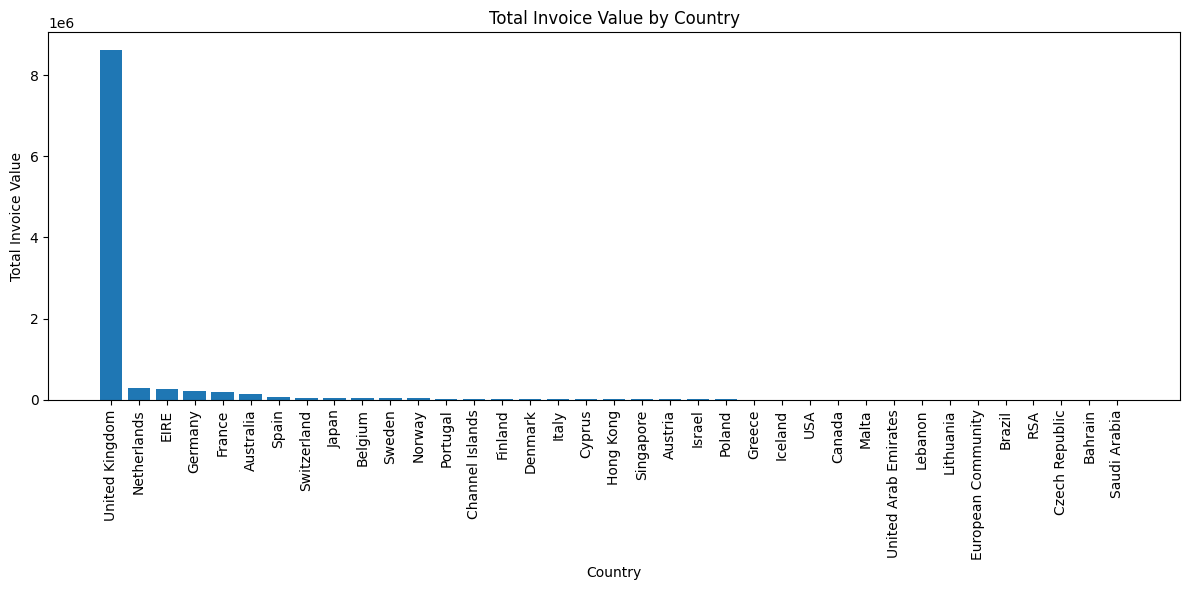

In [10]:
# Plot bar chart showing sum of invoices by country
plt.figure(figsize=(12,6))
plt.bar(country_invoice_sum['Country'], country_invoice_sum['InvoiceValue'])

plt.xticks(rotation=90)  # rotate country names for readability
plt.xlabel('Country')
plt.ylabel('Total Invoice Value')
plt.title('Total Invoice Value by Country')
plt.tight_layout()
plt.show()


This is not very useful as the highest value orders are from the UK. 

The following is order count grouped by region



In [24]:
pivot_invoices_region = pd.pivot_table(
    df_retail_data,
    index="Region",
    values="InvoiceNo",
    aggfunc=pd.Series.nunique
).reset_index().rename(columns={"InvoiceNo": "invoice_count"})

print(pivot_invoices_region)


          Region  invoice_count
0           Asia             38
1         Europe          19652
2    Middle East              3
3  North America             10
4        Oceania             56


---

In [25]:
#As the majority of the orders are in Europe it would be better to do a break down of orders by country in europe    
pivot_invoices_region = pd.pivot_table(
    df_retail_data[df_retail_data["Region"] == "Europe"],
    index="Country",
    values="InvoiceNo",
    aggfunc=pd.Series.nunique
).reset_index().rename(columns={"InvoiceNo": "invoice_count"})

print(pivot_invoices_region)

            Country  invoice_count
0           Austria             17
1           Belgium             98
2   Channel Islands             25
3            Cyprus             14
4           Denmark             18
5              EIRE            284
6           Finland             40
7            France            383
8           Germany            443
9            Greece              5
10          Iceland              7
11            Italy             35
12        Lithuania              4
13            Malta              5
14      Netherlands             93
15           Norway             32
16           Poland             19
17         Portugal             50
18            Spain             88
19           Sweden             34
20      Switzerland             50
21   United Kingdom          17908


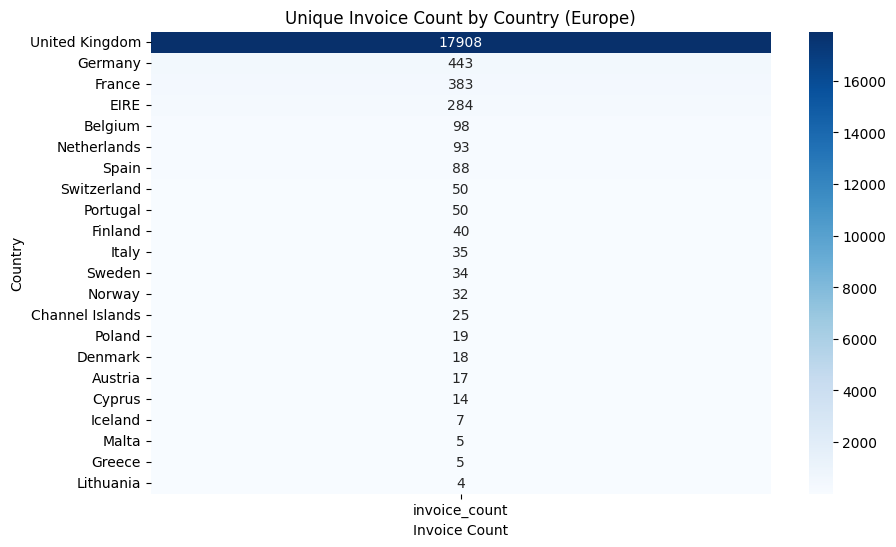

In [26]:
# Sort values for a cleaner heatmap
pivot_invoices_region_sorted = pivot_invoices_region.sort_values("invoice_count", ascending=False)

# Create a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    pivot_invoices_region_sorted.set_index("Country"),
    annot=True, fmt="d", cmap="Blues"
)
plt.title("Unique Invoice Count by Country (Europe)")
plt.ylabel("Country")
plt.xlabel("Invoice Count")
plt.show()


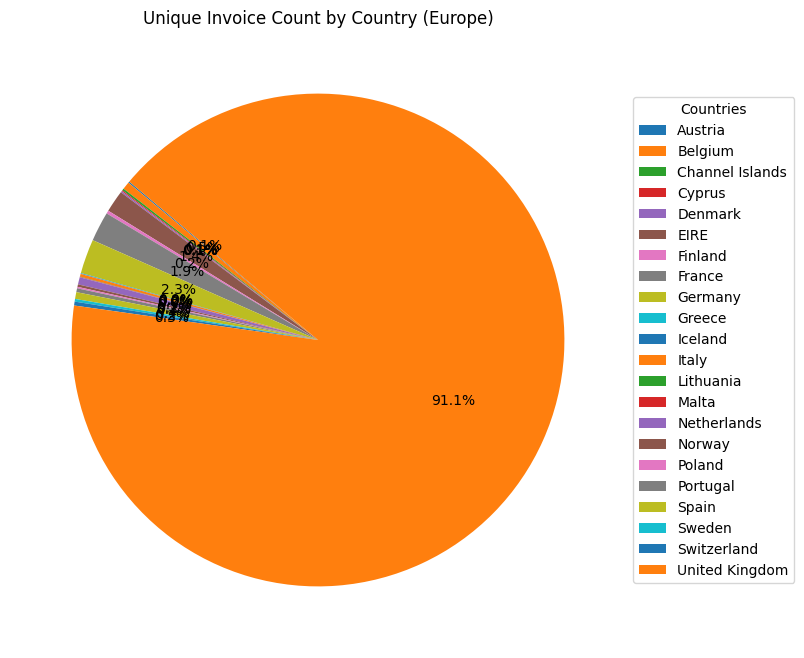

In [ ]:
# Pie chart of unique invoices by country (Europe only)
plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(
    pivot_invoices_region["invoice_count"],
    labels=None,  # remove inline labels for clarity
    autopct="%1.1f%%",
    startangle=140
)

# Add a legend  with country names
plt.legend(
    wedges,
    pivot_invoices_region["Country"],
    title="Countries",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)  # places legend outside chart
)

plt.title("Unique Invoice Count by Country (Europe)")
plt.show()

In [29]:
# Add product group to data from file
df_categories = pd.read_csv("dataset/processed/stockcode_product_group.csv")

print(df_categories.head())

  StockCode                          Description     Product_group
0    85123A   WHITE HANGING HEART T-LIGHT HOLDER           Candles
1     71053                  WHITE METAL LANTERN        Home Decor
2    84406B       CREAM CUPID HEARTS COAT HANGER     Bath & Beauty
3    84029G  KNITTED UNION FLAG HOT WATER BOTTLE  Kitchen & Dining
4    84029E       RED WOOLLY HOTTIE WHITE HEART.     Bath & Beauty


In [30]:
# Merge retail data with product categories
df_merged = df_retail_data .merge(
    df_categories[["StockCode", "Product_group"]],
    on="StockCode",
    how="left"   # keeps all rows from retail data, even if no category is found
)

# Check result
print(df_merged.head())


   InvoiceNo StockCode                         Description  Quantity  \
0     536365    85123A  WHITE HANGING HEART T-LIGHT HOLDER         6   
1     536365    85123A  WHITE HANGING HEART T-LIGHT HOLDER         6   
2     536365     71053                 WHITE METAL LANTERN         6   
3     536365     71053                 WHITE METAL LANTERN         6   
4     536365    84406B      CREAM CUPID HEARTS COAT HANGER         8   

           InvoiceDate  UnitPrice  CustomerID         Country  Region  \
0  2010-12-01 08:26:00       2.55       17850  United Kingdom  Europe   
1  2010-12-01 08:26:00       2.55       17850  United Kingdom  Europe   
2  2010-12-01 08:26:00       3.39       17850  United Kingdom  Europe   
3  2010-12-01 08:26:00       3.39       17850  United Kingdom  Europe   
4  2010-12-01 08:26:00       2.75       17850  United Kingdom  Europe   

  Category ProdCategory  Product_group  
0  Product      Product        Candles  
1  Product      Product        Candles  
2  Pr

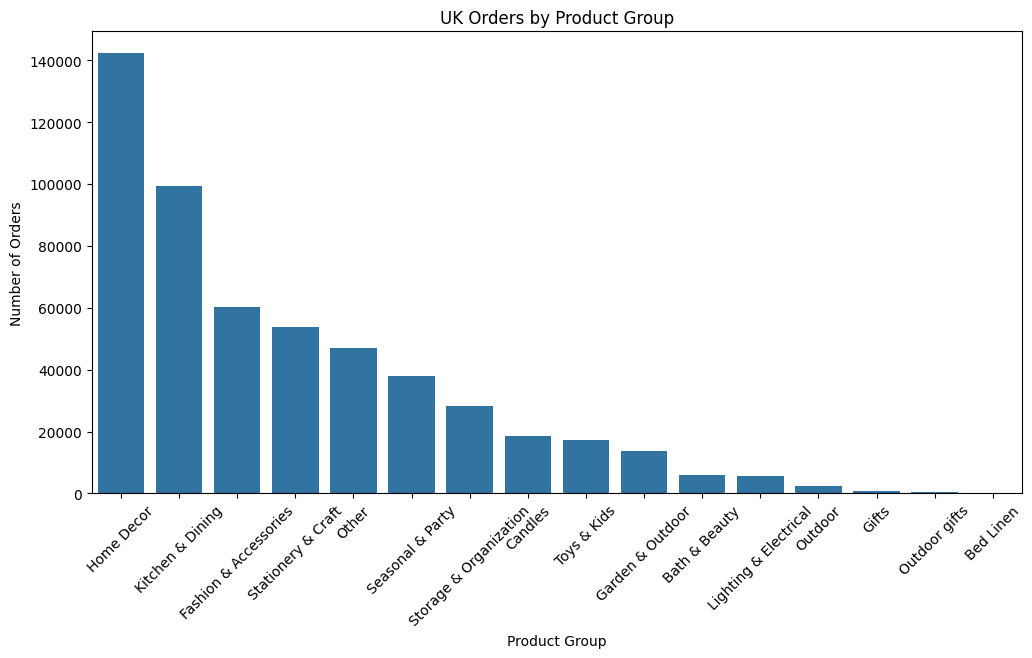

In [31]:
# Create bar chart of UK orders based on product group
plt.figure(figsize=(12, 6))
sns.countplot(
    data=df_merged[df_merged["Country"] == "United Kingdom"],
    x="Product_group",
    order=df_merged["Product_group"].value_counts().index
)
plt.title("UK Orders by Product Group")
plt.xlabel("Product Group")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()


In [33]:
# Convert InvoiceDate to datetime format
df_merged["InvoiceDate"] = pd.to_datetime(df_merged["InvoiceDate"], errors="coerce")

# Group by month and count unique invoice ids
orders_by_month = (
    df_merged.groupby(df_merged["InvoiceDate"].dt.to_period("M"))["InvoiceNo"]
    .nunique()
    .reset_index()
    .rename(columns={"InvoiceNo": "order_count", "InvoiceDate": "Month"})
)

# Convert Month to string
orders_by_month["Month"] = orders_by_month["Month"].astype(str)

print(orders_by_month)


      Month  order_count
0   2010-12         1552
1   2011-01         1081
2   2011-02         1092
3   2011-03         1440
4   2011-04         1235
5   2011-05         1666
6   2011-06         1524
7   2011-07         1448
8   2011-08         1338
9   2011-09         1820
10  2011-10         2007
11  2011-11         2751
12  2011-12          816


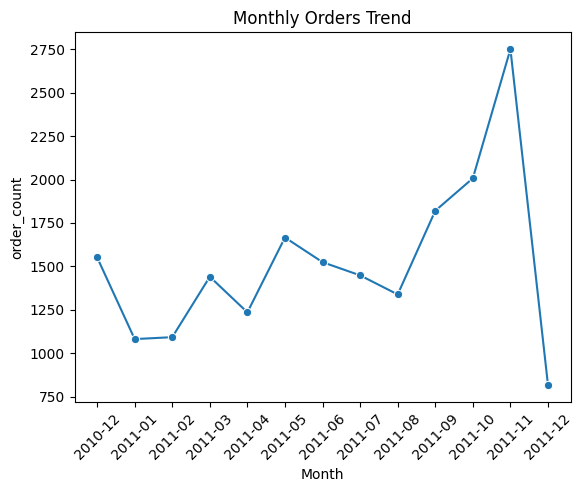

In [34]:
sns.lineplot(data=orders_by_month, x="Month", y="order_count", marker="o")
plt.xticks(rotation=45)
plt.title("Monthly Orders Trend")
plt.show()


In [35]:
# Filter for UK region
df_uk = df_merged[df_merged["Country"] == "United Kingdom"].copy()

# Ensure InvoiceDate is datetime
df_uk["InvoiceDate"] = pd.to_datetime(df_uk["InvoiceDate"], errors="coerce")

# Extract year-month for grouping
df_uk["Month"] = df_uk["InvoiceDate"].dt.to_period("M")

# Group by Month + Product_group and count unique invoices
uk_invoices_by_group_month = (
    df_uk.groupby(["Month", "Product_group"])["InvoiceNo"]
    .nunique()
    .reset_index()
    .rename(columns={"InvoiceNo": "invoice_count"})
)

# Convert Month to string for readability
uk_invoices_by_group_month["Month"] = uk_invoices_by_group_month["Month"].astype(str)

print(uk_invoices_by_group_month.head(20)) 

      Month           Product_group  invoice_count
0   2010-12           Bath & Beauty            350
1   2010-12               Bed Linen             12
2   2010-12                 Candles            528
3   2010-12   Fashion & Accessories            556
4   2010-12        Garden & Outdoor            389
5   2010-12                   Gifts            124
6   2010-12              Home Decor           1184
7   2010-12        Kitchen & Dining           1088
8   2010-12   Lighting & Electrical            228
9   2010-12                   Other            245
10  2010-12                 Outdoor            182
11  2010-12           Outdoor gifts            157
12  2010-12        Seasonal & Party            656
13  2010-12      Stationery & Craft            686
14  2010-12  Storage & Organization            639
15  2010-12             Toys & Kids            509
16  2011-01           Bath & Beauty            247
17  2011-01               Bed Linen              6
18  2011-01                 Can

NOTE

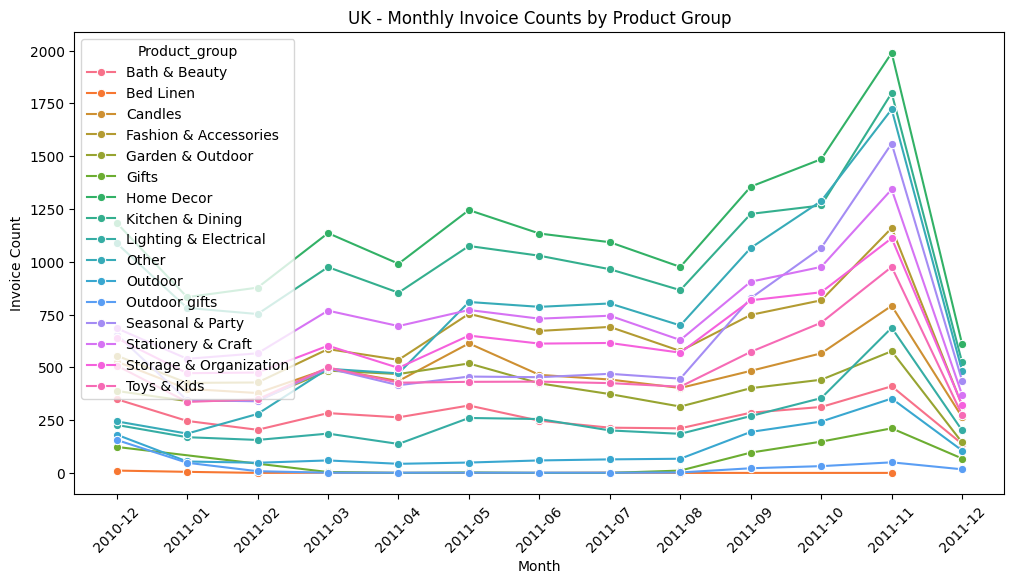

In [36]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=uk_invoices_by_group_month,
    x="Month", y="invoice_count", hue="Product_group", marker="o"
)
plt.xticks(rotation=45)
plt.title("UK - Monthly Invoice Counts by Product Group")
plt.ylabel("Invoice Count")
plt.show()

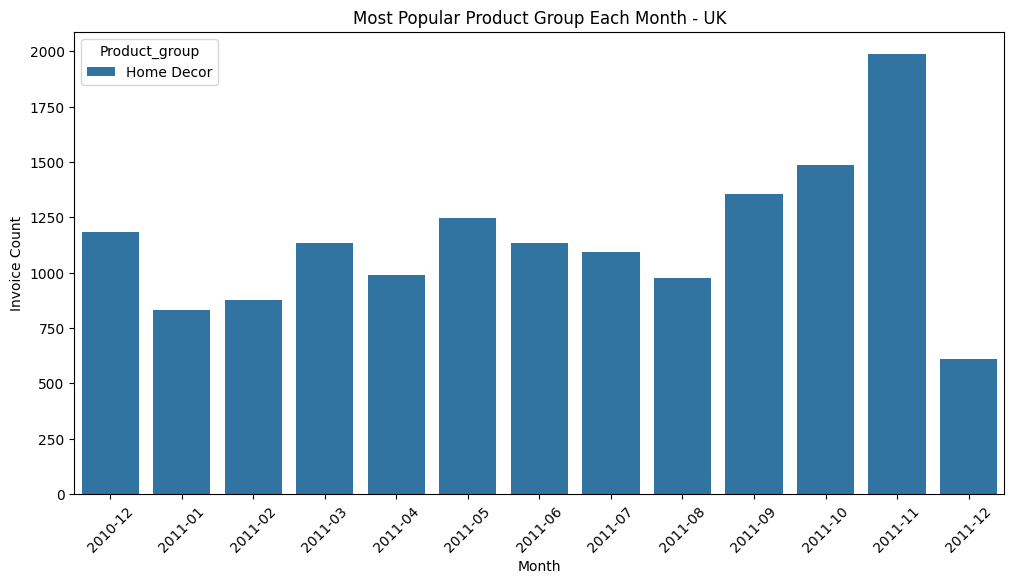

In [41]:
# Filter for UK region
df_uk = df_merged[df_merged["Country"] == "United Kingdom"].copy()
df_uk["InvoiceDate"] = pd.to_datetime(df_uk["InvoiceDate"], errors="coerce")
df_uk["Month"] = df_uk["InvoiceDate"].dt.to_period("M")

# Count invoices per product group per month
uk_grouped = (
    df_uk.groupby(["Month", "Product_group"])["InvoiceNo"]
    .nunique()
    .reset_index()
    .rename(columns={"InvoiceNo": "invoice_count"})
)

# For each month, get the product group with the max invoices
uk_top_products = uk_grouped.loc[
    uk_grouped.groupby("Month")["invoice_count"].idxmax()
]

# Convert Month to string for plotting
uk_top_products["Month"] = uk_top_products["Month"].astype(str)

# Bar chart of most popular product group each month
plt.figure(figsize=(12,6))
sns.barplot(
    data=uk_top_products,
    x="Month", y="invoice_count", hue="Product_group"
)
plt.xticks(rotation=45)
plt.title("Most Popular Product Group Each Month - UK")
plt.ylabel("Invoice Count")
plt.show()


In [50]:
# Ensure InvoiceDate is datetime and calculate monthly order counts (unique invoices)
df_merged["InvoiceDate"] = pd.to_datetime(df_merged["InvoiceDate"], errors="coerce")
orders_by_month = (
    df_merged.groupby(df_merged["InvoiceDate"].dt.to_period("M"))["InvoiceNo"]
    .nunique()
    .reset_index()
    .rename(columns={"InvoiceNo": "order_count", "InvoiceDate": "Month"})
)
# Convert Period to a timestamp at month start for a proper continuous time axis
orders_by_month["Month"] = orders_by_month["Month"].dt.to_timestamp()

import plotly.express as px

fig = px.line(
    orders_by_month,
    x="Month",
    y="order_count",
    title="Interactive: Monthly Orders Trend",
    markers=True
)
# Add a rangeslider and some quick range buttons
fig.update_xaxes(
    rangeslider_visible=True,
    rangeselector=dict(
        buttons=list([
            dict(count=3, label="3m", step="month", stepmode="backward"),
            dict(count=6, label="6m", step="month", stepmode="backward"),
            dict(count=12, label="1y", step="month", stepmode="backward"),
            dict(step="all")
        ])
    )
)
fig.update_layout(hovermode="x unified")

fig.show()


c:\vscode_projects\Hack1_Online_Retail\.venv\Lib\site-packages\_plotly_utils\basevalidators.py:105: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

* You may add as many sections as you want, as long as it supports your project workflow.
* All notebook's cells should be run top-down (you can't create a dynamic wherein a given point you need to go back to a previous cell to execute some task, like go back to a previous cell and refresh a variable content)

---

# Push files to Repo

* In cases where you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [ ]:
import os
try:
  # create your folder here
  # os.makedirs(name='')
except Exception as e:
  print(e)
